In [1]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("monthly-beer-production-in-austr.csv")

df.head()

,Month,Monthly beer production
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9


In [3]:
# =========================
# 3. Basic Cleaning
# =========================

# Ensure column names are clean
df.columns = df.columns.str.strip()

# Try to detect common structure
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    476 non-null    str    
 1   Monthly beer production  476 non-null    float64
dtypes: float64(1), str(1)
memory usage: 10.8 KB
None


In [4]:
# =========================
# 4. Convert Date Column
# =========================
# Assumes dataset has a "Month" or "Date" column
# Adjust if needed

df['Month'] = pd.to_datetime(df['Month'])

df = df.sort_values('Month')

df.set_index('Month', inplace=True)

df.head()

,Monthly beer production
Month,
1956-01-01,93.2
1956-02-01,96.0
1956-03-01,95.2
1956-04-01,77.1
1956-05-01,70.9


In [5]:
# =========================
# 5. Feature Engineering
# =========================

# Target variable assumed as "Monthly beer production"
# Adjust column name if needed

target_col = df.columns[0]  # usually first column is production

df['month'] = df.index.month
df['year'] = df.index.year

# Lag features (important for time series)
df['lag_1'] = df[target_col].shift(1)
df['lag_2'] = df[target_col].shift(2)
df['lag_3'] = df[target_col].shift(3)

# Drop NaN values from lagging
df = df.dropna()

df.head()

,Monthly beer production,month,year,lag_1,lag_2,lag_3
Month,,,,,,
1956-04-01,77.1,4,1956,95.2,96.0,93.2
1956-05-01,70.9,5,1956,77.1,95.2,96.0
1956-06-01,64.8,6,1956,70.9,77.1,95.2
1956-07-01,70.1,7,1956,64.8,70.9,77.1
1956-08-01,77.3,8,1956,70.1,64.8,70.9


In [6]:
# =========================
# 6. Define Features & Target
# =========================

X = df.drop(columns=[target_col])
y = df[target_col]

print(X.shape, y.shape)

(473, 5) (473,)


In [7]:
# =========================
# 7. Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # important for time series
)

In [8]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Create the model
rf_model = RandomForestRegressor(random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions
rf_pred = rf_model.predict(X_test)

# 4. Evaluate performance
print("Random Forest Performance")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Performance
MAE: 9.506052631578951
RMSE: 11.59883825625381


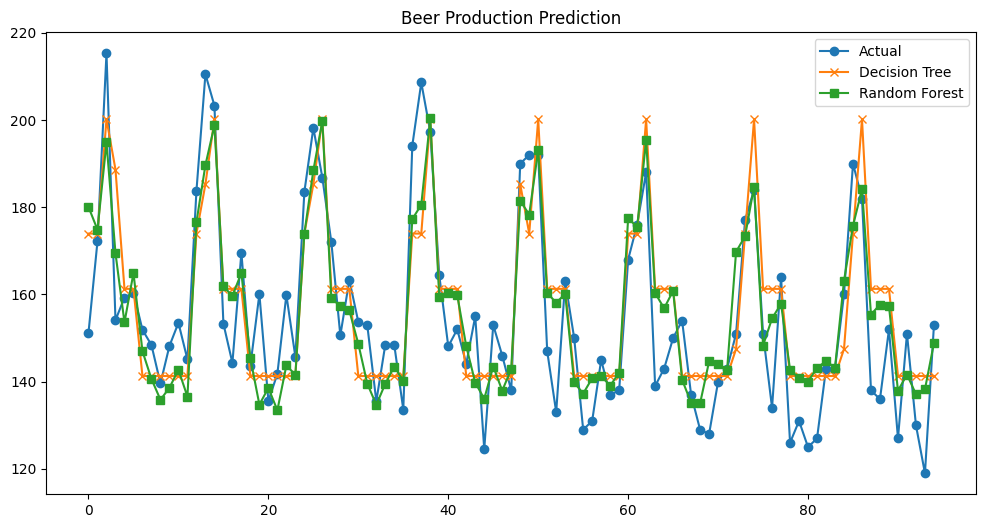

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(dt_pred, label="Decision Tree", marker='x')
plt.plot(rf_pred, label="Random Forest", marker='s')

plt.title("Beer Production Prediction")
plt.legend()
plt.show()